In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AffinityPropagation, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

In [ ]:
def clustering_metrics(X, labels_true, labels_pred):
    metrics = {}

    metrics['ARI'] = adjusted_rand_score(labels_true, labels_pred)
    metrics['NMI'] = normalized_mutual_info_score(labels_true, labels_pred)

    metrics['Silhouette'] = silhouette_score(X, labels_pred)
    metrics['Davies-Bouldin'] = davies_bouldin_score(X, labels_pred)

    return metrics

In [ ]:
def build_table(results):
    rows = []
    for model, metrics_dict in results.items():
        row = {'Модель': model}
        row.update(metrics_dict)
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Модель')

    metric_order = ['ARI', 'NMI', 'Silhouette', 'Davies-Bouldin']
    return df[metric_order]

In [59]:
def plot_clusters(X, labels, title, centers=None):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolors='black')
    plt.title(title)
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.show()

In [48]:
def plot_elbow(X, title):
    inertias = []

    for i in range(2, 10):
        m = KMeans(i, n_init='auto', random_state=42).fit(X)
        inertias.append(m.inertia_)

    plt.plot(range(2,10), inertias)
    plt.title(title)
    plt.show()

In [49]:
def plot_silhouette(X, title):
    ss = []

    for i in range(2, 10):
        ss.append(silhouette_score(X, KMeans(i, n_init='auto', random_state=42).fit(X).labels_))

    plt.plot(range(2,10), ss)
    plt.title(title)
    plt.show()

In [50]:
def plot_neighbours(X, title):
    nbrs = NearestNeighbors(n_neighbors=4).fit(X)
    distances, indices = nbrs.kneighbors(X)
    distances = np.mean(distances, axis=1)
    distances = np.sort(distances)
    plt.title(title)
    plt.plot(distances)
    plt.show()

In [51]:
def plot_dendrogram(X, title):
    clusters = linkage(X, method="ward")

    plt.figure(figsize=(8, 6))
    dendrogram = dendrogram(clusters)
    plt.axhline(25, color='red', linestyle='--');
    plt.axhline(15, color='crimson');
    plt.title(title)
    plt.show()

In [ ]:
df = pd.read_csv("../csv/cl_finished.csv", sep = ";")
X = df.drop(columns="Diabetes_012")
y = df["Diabetes_012"]

X, _, y, _ = train_test_split(X, y, test_size = 0.7, random_state=RANDOM_STATE, stratify=y)

In [53]:
X_mkcl, y_mkcl = make_classification(
    n_samples=3000, 
    n_features=2, 
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=RANDOM_STATE
)

X_mkcl_train, y_mkcl_train, X_mkcl_test, y_mkcl_test = train_test_split(X_mkcl, y_mkcl, test_size=0.3, random_state=RANDOM_STATE)

X_mkbl, y_mkbl = make_blobs(
    n_samples=3000,
    n_features=2,
    centers=4,
    random_state=RANDOM_STATE
)

X_mkbl_train, y_mkbl_train, X_mkbl_test, y_mkbl_test = train_test_split(X_mkbl, y_mkbl, test_size=0.3, random_state=RANDOM_STATE)

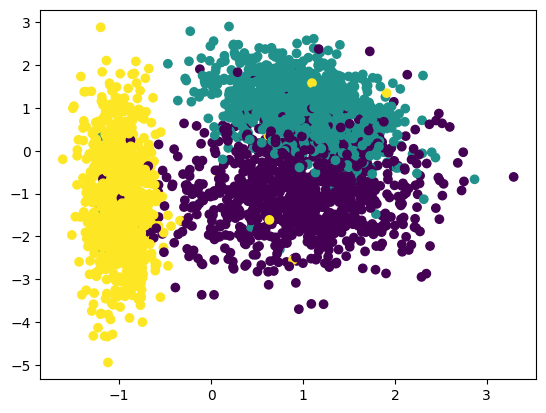

In [54]:
plt.scatter(X_mkcl[:, 0], X_mkcl[:, 1], c=y_mkcl)

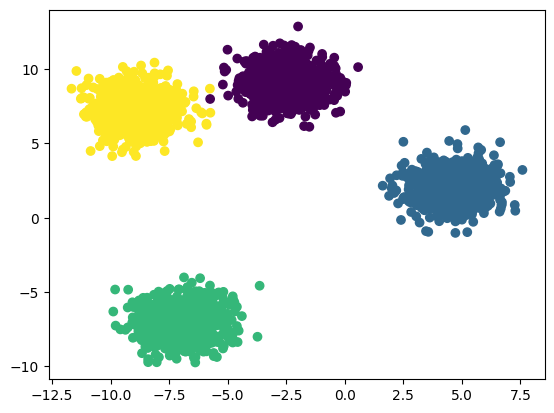

In [55]:
plt.scatter(X_mkbl[:, 0], X_mkbl[:, 1], c=y_mkbl)

In [56]:
scaler = StandardScaler()
X_mkcl = scaler.fit_transform(X_mkcl)
X_mkbl = scaler.fit_transform(X_mkbl)
X = scaler.fit_transform(X)

In [57]:
dfs = {'clf': (X_mkcl, y_mkcl), 'blob': (X_mkbl, y_mkbl), 'real': (X, y)}

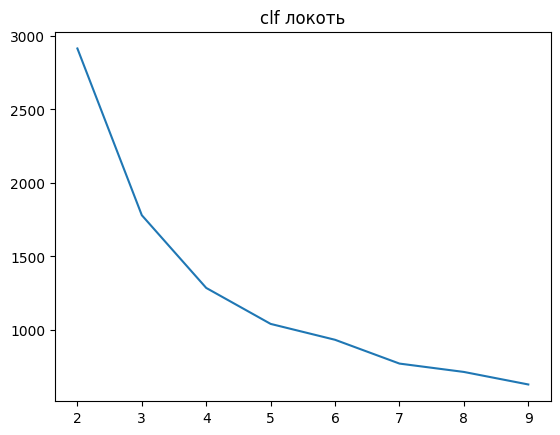

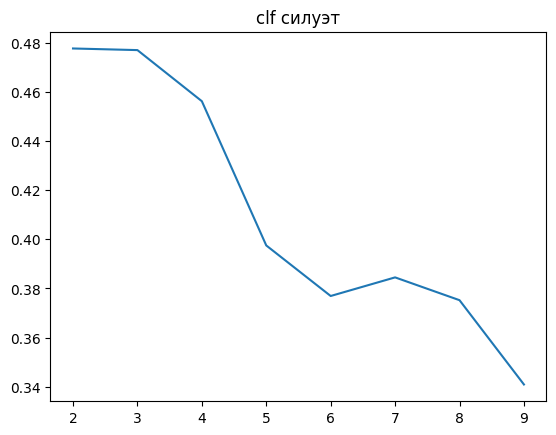

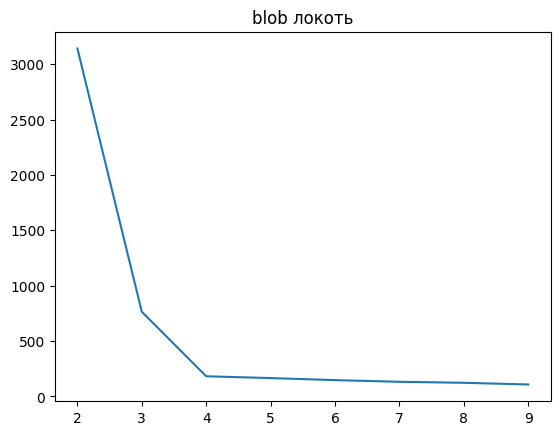

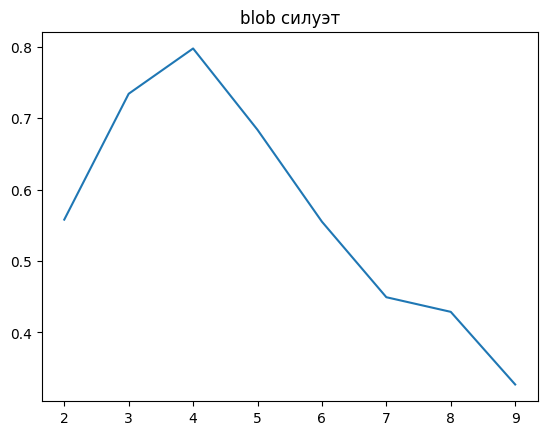

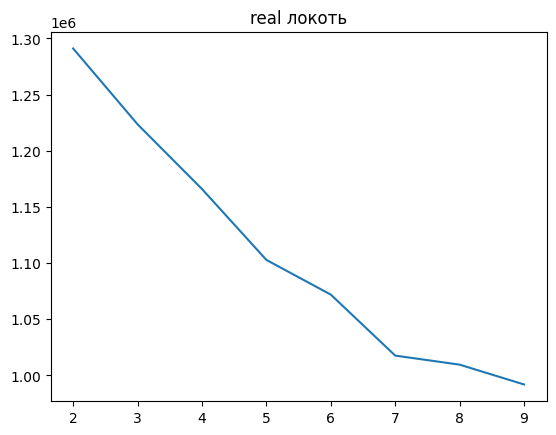

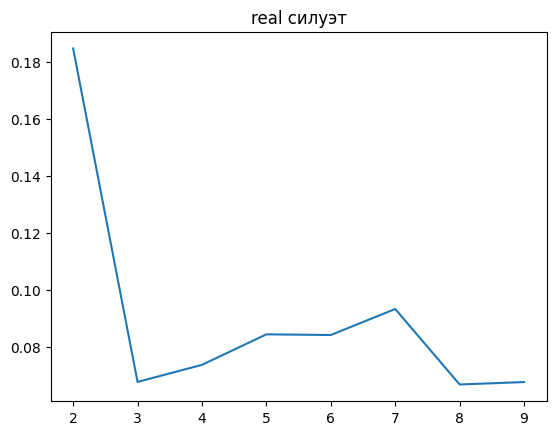

In [58]:
for df in dfs:
    plot_elbow(dfs[df][0], f'{df} локоть')
    plot_silhouette(dfs[df][0], f'{df} силуэт')
    print('\n\n')

*CLF - 3* \
*BLOB - 4* \
*REAL - 2*

In [60]:
models = {'clf': {}, 'blob': {}, 'real': {}}

In [61]:
clf_kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
clf_labels = clf_kmeans.fit_predict(X_mkcl)
models['clf']['KMeans'] = (clf_kmeans, clf_labels)

blob_kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
blob_labels = blob_kmeans.fit_predict(X_mkbl)
models['blob']['KMeans'] = (blob_kmeans, blob_labels)

real_kmeans = KMeans(n_clusters=2, n_init='auto', random_state=42)
real_labels = real_kmeans.fit_predict(X)
models['real']['KMeans'] = (real_kmeans, real_labels)

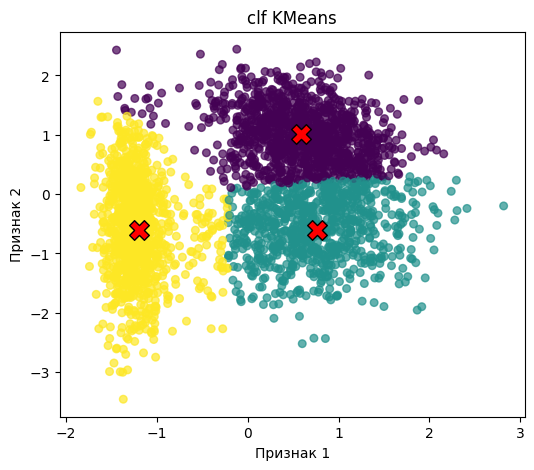

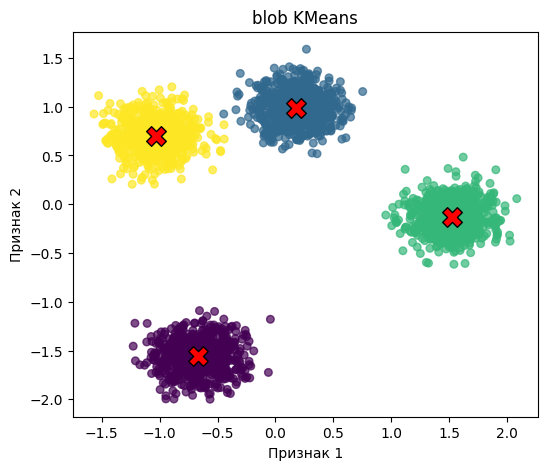

In [62]:
for df in ['clf', 'blob']:
    model = models[df]['KMeans'][0]
    labels = models[df]['KMeans'][1]
    centers = model.cluster_centers_
    plot_clusters(dfs[df][0], labels, f'{df} KMeans', centers)
    print()

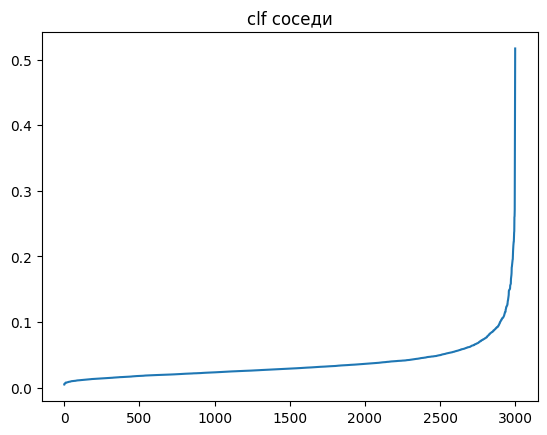

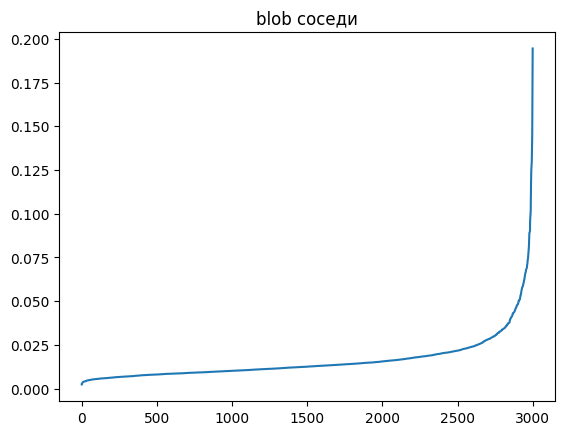

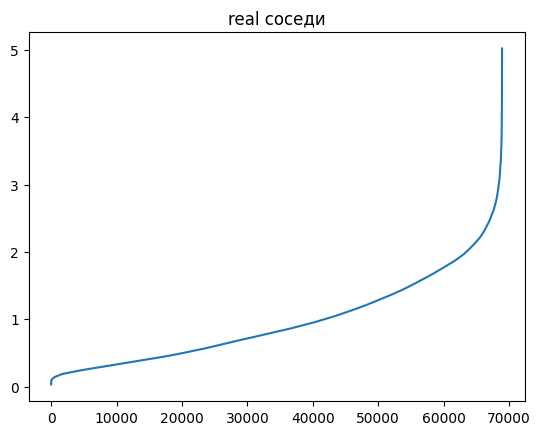

In [63]:
for df in dfs:
    plot_neighbours(dfs[df][0], f'{df} соседи')
    print('\n')

*CLF - 0.08* \
*BLOB - 0.03* \
*REAL - 2*

In [64]:
clf_dbscan = DBSCAN(eps=0.08, min_samples=4).fit(X_mkcl)
clf_labels = clf_dbscan.labels_
models['clf']['DBSCAN'] = (clf_dbscan, clf_labels)

blob_dbscan = DBSCAN(eps=0.03, min_samples=4).fit(X_mkbl)
blob_labels = blob_dbscan.labels_
models['blob']['DBSCAN'] = (blob_dbscan, blob_labels)

real_dbscan = DBSCAN(eps=2, min_samples=4).fit(X)
real_labels = real_dbscan.labels_
models['real']['DBSCAN'] = (real_dbscan, real_labels)

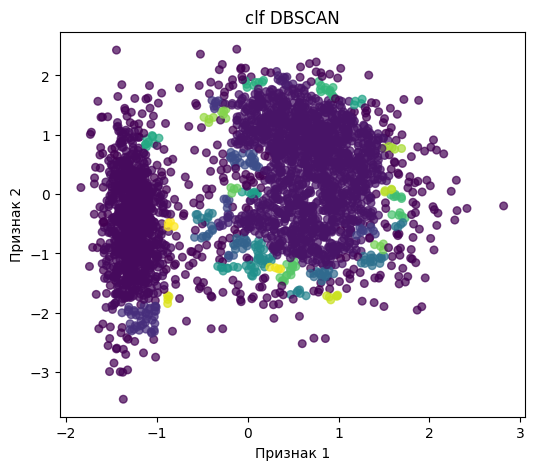

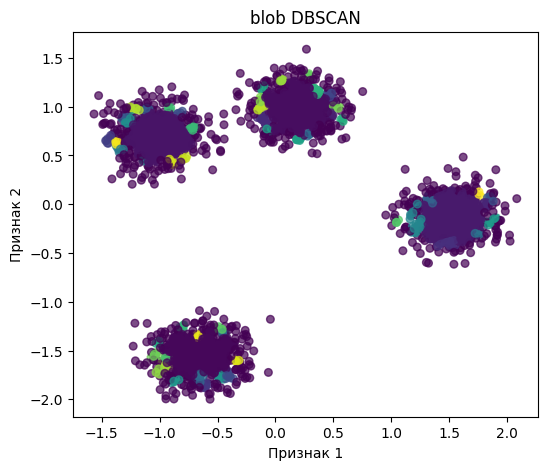

In [65]:
for df in ['clf', 'blob']:
    model = models[df]['DBSCAN'][0]
    labels = models[df]['DBSCAN'][1]
    plot_clusters(dfs[df][0], labels, f'{df} DBSCAN')
    print()

In [66]:
clf_gm = GaussianMixture(n_components=3).fit(X_mkcl)
clf_labels = clf_gm.predict(X_mkcl)
models['clf']['GM'] = (clf_gm, clf_labels)

blob_gm = GaussianMixture(n_components=4).fit(X_mkbl)
blob_labels = blob_gm.predict(X_mkbl)
models['blob']['GM'] = (blob_gm, blob_labels)

real_gm = GaussianMixture(n_components=2).fit(X)
real_labels = real_gm.predict(X)
models['real']['GM'] = (real_gm, real_labels)

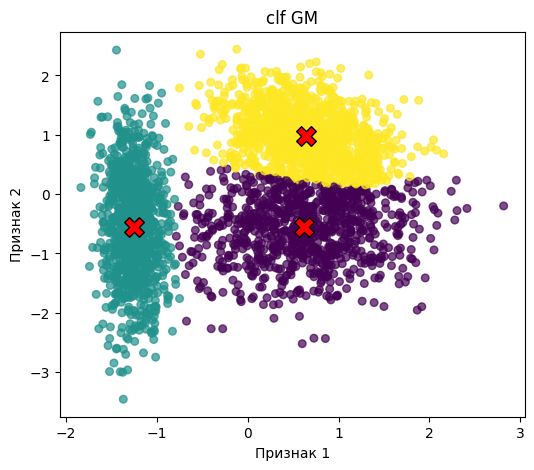

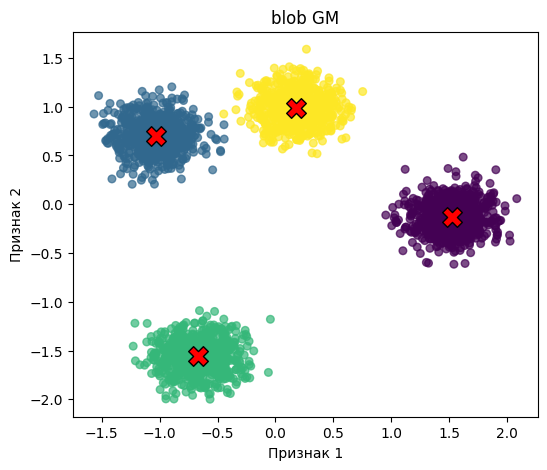

In [67]:
for df in ['clf', 'blob']:
    model = models[df]['GM'][0]
    labels = models[df]['GM'][1]
    centers = model.means_
    plot_clusters(dfs[df][0], labels, f'{df} GM', centers)
    print()

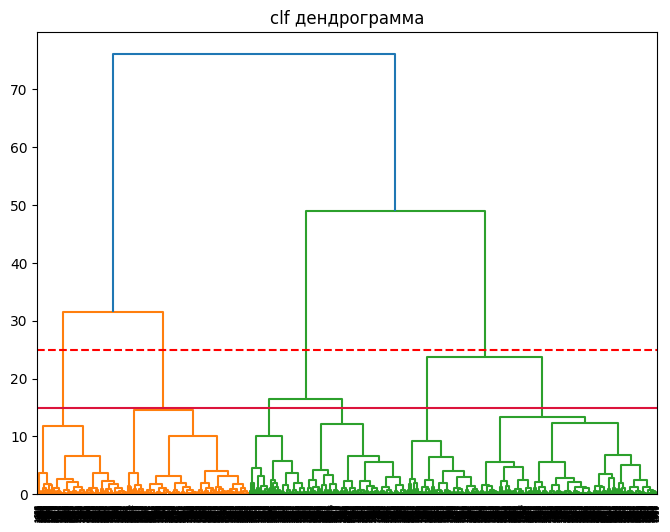

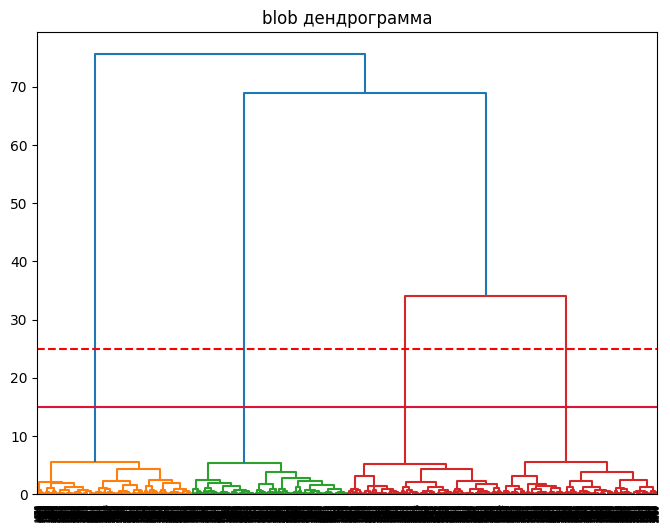

In [ ]:
for df in dfs:
    X = dfs[df][0]
    clusters = linkage(X, method="ward")

    plt.figure(figsize=(8, 6))
    dendrogram_plot = dendrogram(clusters)
    plt.axhline(25, color='red', linestyle='--');
    plt.axhline(15, color='crimson');
    plt.title(f'{df} дендрограмма')
    plt.show()
    print('\n')

In [ ]:
clf_ac = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_mkcl)
clf_labels = clf_ac.labels_
models['clf']['AC'] = (clf_ac, clf_labels)

blob_ac = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(X_mkbl)
blob_labels = blob_ac.labels_
models['blob']['AC'] = (blob_ac, blob_labels)

real_ac = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(X)
real_labels = real_ac.labels_
models['real']['AC'] = (real_ac, real_labels)

In [ ]:
for df in ['clf', 'blob']:
    model = models[df]['AC'][0]
    labels = models[df]['AC'][1]
    plot_clusters(dfs[df][0], labels, f'{df} AC')
    print()

In [ ]:
clf_ap = AffinityPropagation(preference=-5).fit(X_mkcl)
clf_labels = clf_ap.labels_
models['clf']['AP'] = (clf_ap, clf_labels)

blob_ap = AffinityPropagation(preference=-5).fit(X_mkbl)
blob_labels = blob_ap.labels_
models['blob']['AP'] = (blob_ap, blob_labels)

real_ap = AffinityPropagation(preference=-5).fit(X)
real_labels = real_ap.labels_
models['real']['AP'] = (real_ap, real_labels)

In [ ]:
for df in ['clf', 'blob']:
    model = models[df]['AP'][0]
    labels = models[df]['AP'][1]
    centers = model.cluster_centers_
    plot_clusters(dfs[df][0], labels, f'{df} AP', centers)
    print()

In [ ]:
algs = ['KMeans', 'DBSCAN', 'GM', 'AC', 'AP']

In [ ]:
results = {}
for df in dfs:
    for alg in algs:
        labels = models[df][alg][1]
        print(len(labels), len(dfs[df][1]))
        results[f'{df}_{alg}'] = clustering_metrics(dfs[df][0], dfs[df][1], labels)

In [ ]:
build_table(results)

In [ ]:
class MyKMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx].copy()

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            new_centroids = np.array([X[self.labels_ == k].mean(axis=0) for k in range(self.n_clusters)])
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [ ]:
clf_mykmeans = MyKMeans(n_clusters=3).fit(X_mkcl)
clf_labels = clf_mykmeans.predict(X_mkcl)
models['clf']['MyKMeans'] = (clf_mykmeans, clf_labels)

blob_mykmeans = MyKMeans(n_clusters=4).fit(X_mkbl)
blob_labels = blob_mykmeans.predict(X_mkbl)
models['blob']['MyKMeans'] = (blob_mykmeans, blob_labels)

real_mykmeans = MyKMeans(n_clusters=2).fit(X)
real_labels = real_mykmeans.predict(X)
models['real']['MyKMeans'] = (real_mykmeans, real_labels)

In [ ]:
results['clf_MyKMeans'] = clustering_metrics(X_mkcl, y_mkcl, clf_labels)
results['blob_MyKMeans'] = clustering_metrics(X_mkbl, y_mkbl, blob_labels)
results['real_MyKMeans'] = clustering_metrics(X, y, real_labels)


In [ ]:
build_table(results)

In [ ]:
for df in ['clf', 'blob']:
    model = models[df]['MyKMeans'][0]
    labels = models[df]['MyKMeans'][1]
    centers = model.centroids
    plot_clusters(dfs[df][0], labels, f'{df} MyKMeans', centers)
    print()